Membros da Equipe:

Fellas Soares

Mousinho

Gabriel Ribeirão Pereira

Giorno Giovanni (o Vicenzo esqueceu de ti)

Vicenzo Poggers

# Estudo de Caso 1:

O estudo de caso 1 envolve a aplicação prática de um problema de
Ciência de Dados relacionado a Machine Learning. Você vai abordar o
problema de Detecção de Transações Fraudulentas, utilizando o conjunto
de dados disponível em Fraud Transaction Detection
(https://www.kaggle.com/code/llabhishekll/fraud-transaction-detection/input) . O objetivo é desenvolver um modelo que seja capaz de
prever se uma transação é fraude ou não. Você pode se inspirar no
notebook presente em (https://www.kaggle.com/code/llabhishekll/fraud-transaction-detection/notebook). Para este problema de dados, você deve
realizar as seguintes etapas:

a) Elabore a análise exploratória da base de dados - análise gráfica e
por tabelas. (25%)

b) Realize a previsão por modelos criados utilizando os algoritmos
trabalhados em sala de aula, KNN, Árvore de Decisão e Regressão
Logística. Compare os resultados.(40%)

c) Encontre as features mais importantes para a detecção de fraudes,
interprete os resultados. (10%)

d) Apresente a matriz de confusão, acurácia, precisão e recall (15%)

e) Realize ajustes a fim de melhorar o desempenho do modelo e
apresente os resultados. (10%)

Lembre-se de fornecer explicações detalhadas e apresentar os cálculos,
gráficos e conclusões de forma clara e organizada.
Você deve anexar o notebook utilizado.

## Análise exploratória

In [ ]:
# Importando o Panda e o arquivo do google drive
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Altere o caminho se preciso
caminho_arquivo = '/content/drive/MyDrive/fraud_transaction_detection.csv/fraud_transaction_detection.csv'
base_fraude = pd.read_csv(caminho_arquivo)

In [ ]:
# Visualizando as 5 primeiras linhas
base_fraude.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Verificando o tamanho da base
base_fraude.shape

(6362620, 11)

In [ ]:
# Verificando os tipos de dados
base_fraude.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step - Maps a unit of time in the real world. In this case 1 step is 1 hour of time

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER

amount - amount of the transaction in local currency

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrg - customer's balance after the transaction

nameDest - recipient ID of the transaction

oldbalanceDest - initial recipient balance before the transaction

newbalanceDest - recipient's balance after the transaction

isFraud - identifies a fraudulent transaction (1) and non fraudulent (0)

isFlaggedFraud - flags illegal attempts to transfer more than 200.000 in a single transaction.

In [ ]:
# Contando a quantidade de valores nulos
base_fraude.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
base_fraude = base_fraude.dropna()

In [ ]:
# Verificando as informações estatísticas
base_fraude.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
base_fraude.nunique()

,0
step,743
type,5
amount,5316900
nameOrig,6353307
oldbalanceOrg,1845844
newbalanceOrig,2682586
nameDest,2722362
oldbalanceDest,3614697
newbalanceDest,3555499
isFraud,2


In [ ]:
# Vendo se a coluna type possui alguma conexäo com com a coluna is Fraud
base_fraude.loc[base_fraude.isFraud == 1].type.unique()

array(['TRANSFER', 'CASH_OUT'], dtype=object)

In [ ]:
# Deletando as colunas nameOrig e nameDest
base_fraude.rename(columns={'newbalanceOrig':'newbalanceOrg'},inplace=True)
base_fraude.drop(labels=['nameOrig','nameDest'],axis=1,inplace=True)

In [ ]:
# Importando o matplotlib e o seaborn
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Dividindo a base de dados para treino e teste
from sklearn.model_selection import train_test_split

base_fraude, teste_fraude = train_test_split(base_fraude, test_size=0.6)

In [ ]:
# Criando uma matriz de correlação entre as variáveis
base_fraude.corr(numeric_only=True)

,step,amount,oldbalanceOrg,newbalanceOrg,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.023140,-0.009717,-0.010044,0.027096,0.025469,0.031279,0.003942
amount,0.023140,1.000000,-0.002682,-0.007952,0.292233,0.456228,0.078637,0.009881
oldbalanceOrg,-0.009717,-0.002682,1.000000,0.998791,0.066268,0.042124,0.010880,0.002876
newbalanceOrg,-0.010044,-0.007952,0.998791,1.000000,0.067848,0.041940,-0.007685,0.002827
oldbalanceDest,0.027096,0.292233,0.066268,0.067848,1.000000,0.976856,-0.006339,-0.000610
newbalanceDest,0.025469,0.456228,0.042124,0.041940,0.976856,1.000000,0.000235,-0.000628
isFraud,0.031279,0.078637,0.010880,-0.007685,-0.006339,0.000235,1.000000,0.052909
isFlaggedFraud,0.003942,0.009881,0.002876,0.002827,-0.000610,-0.000628,0.052909,1.000000


<Axes: >

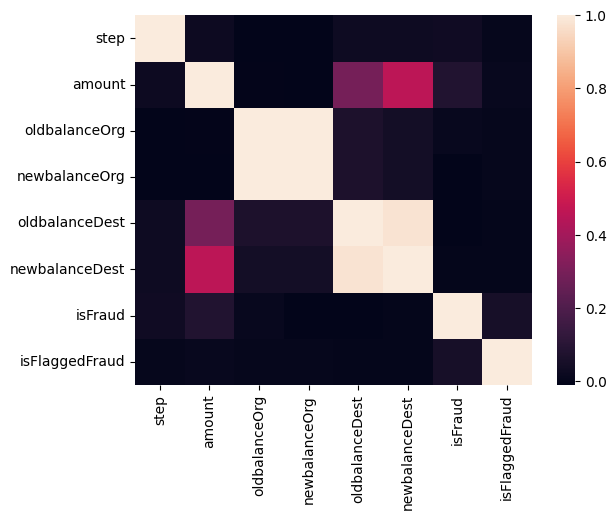

In [ ]:
# Utilizando o heatmap do seaborn para tornar essa matriz mais visual
sns.heatmap(base_fraude.corr(numeric_only=True))

In [ ]:
fraud = base_fraude.loc[base_fraude.isFraud == 1]
nonfraud = base_fraude.loc[base_fraude.isFraud == 0]

In [ ]:
fraudcount = fraud.isFraud.count()
nonfraudcount = nonfraud.isFraud.count()

In [ ]:
# Deletando as colunas object
colunas_fraude = base_fraude.select_dtypes(include=['object']).columns
base_fraude = base_fraude.drop(colunas_fraude, axis=1)
teste_fraude = teste_fraude.drop(colunas_fraude, axis=1)

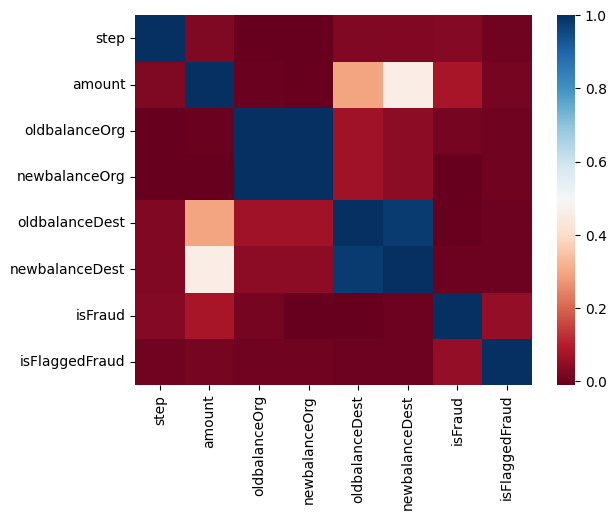

In [ ]:
sns.heatmap(base_fraude.corr(),cmap='RdBu',);

##previsão por modelos criados utilizando os algoritmos trabalhados em sala de aula

In [ ]:
# Definindo o X e y para o treino
X_treino = base_fraude.drop("isFraud", axis=1)
Y_treino = base_fraude.isFraud

# Definindo o X e y para o teste
X_teste = teste_fraude.drop("isFraud", axis=1)
Y_teste = teste_fraude.isFraud

In [ ]:
# Importando os algoritmos e criando os classificadores
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)

from sklearn import tree
clfArvore = tree.DecisionTreeClassifier(random_state=0)

from sklearn.linear_model import LogisticRegression
clfLog = LogisticRegression(random_state=0,max_iter=1000)

In [ ]:
# Fazendo o fit do modelo
neight = neigh.fit(X_treino, Y_treino)

clfArvore = clfArvore.fit(X_treino, Y_treino)

clfLog = clfLog.fit(X_treino, Y_treino)

In [ ]:
# Fazendo a predicão
pred_KNN = neigh.predict(X_teste)

pred_Arvore = clfArvore.predict(X_teste)

pred_Log = clfLog.predict(X_teste)

In [ ]:
# Importando as métricas de avaliação
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [ ]:
# Matriz de confusão
confusion_matrix(Y_teste, pred_KNN)

array([[3811889,     681],
       [   1580,    3422]])

In [ ]:
confusion_matrix(Y_teste, pred_Arvore)

array([[3811714,     856],
       [   1083,    3919]])

In [ ]:
confusion_matrix(Y_teste, pred_Log)

array([[3812318,     252],
       [   2618,    2384]])

In [ ]:
# Acurácia
print(accuracy_score(Y_teste,pred_KNN))
print(accuracy_score(Y_teste,pred_Arvore))
print(accuracy_score(Y_teste,pred_Log))

0.9994077387407494
0.9994920855454723
0.9992482132622516


In [ ]:
# Precisão
print(precision_score(Y_teste,pred_KNN))
print(precision_score(Y_teste,pred_Arvore))
print(precision_score(Y_teste,pred_Log))

0.8340238849622228
0.8207329842931937
0.9044006069802731


In [ ]:
# Recall
print(recall_score(Y_teste,pred_KNN))
print(recall_score(Y_teste,pred_Arvore))
print(recall_score(Y_teste,pred_Log))

0.6841263494602159
0.7834866053578569
0.476609356257497


## Analise dos dados

In [ ]:
# Reimportando o csv
caminho_arquivo = '/content/drive/MyDrive/fraud_transaction_detection.csv/fraud_transaction_detection.csv'
base_fraude = pd.read_csv(caminho_arquivo)

In [ ]:
# Converteno a coluna type em int
# Criando uma coluna para cada opção
base_fraude['iscashout'] = base_fraude.type.apply(lambda x:1 if x == 'CASH_OUT' else 0)
base_fraude['iscashin'] = base_fraude.type.apply(lambda x:1 if x == 'CASH_IN' else 0)
base_fraude['ispayment'] = base_fraude.type.apply(lambda x:1 if x == 'PAYMENT' else 0)
base_fraude['istransfer'] = base_fraude.type.apply(lambda x:1 if x == 'TRANSFER' else 0)
base_fraude['isdebit'] = base_fraude.type.apply(lambda x:1 if x == 'debit' else 0)

In [ ]:
# Visualizando as 5 primeiras linhas
base_fraude.head(5)

In [ ]:
# Deletando as colunas object
colunas_fraude = base_fraude.select_dtypes(include=['object']).columns
base_fraude = base_fraude.drop(colunas_fraude, axis=1)

In [ ]:
# Visualizando as 5 primeiras linhas
base_fraude.head(5)

In [ ]:
# Utilizando o heatmap do seaborn para tornar essa matriz mais visual
sns.heatmap(base_fraude.corr(numeric_only=True))

In [ ]:
# Dividindo a base de dados para treino e teste
from sklearn.model_selection import train_test_split

base_fraude, teste_fraude = train_test_split(base_fraude, test_size=0.9)